In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("Set2")

df = pd.read_csv('/Users/prernamalhotra/CRIME/crime-analysis-prediction/data/crime_data_cleaned.csv')
print(f"Loaded {df.shape[0]:,} records")
print(df['Crime Category'].value_counts())

Loaded 1,419,631 records
Crime Category
Property        618956
Violent         419007
Other           216317
Drug            131214
Public Order     34137
Name: count, dtype: int64


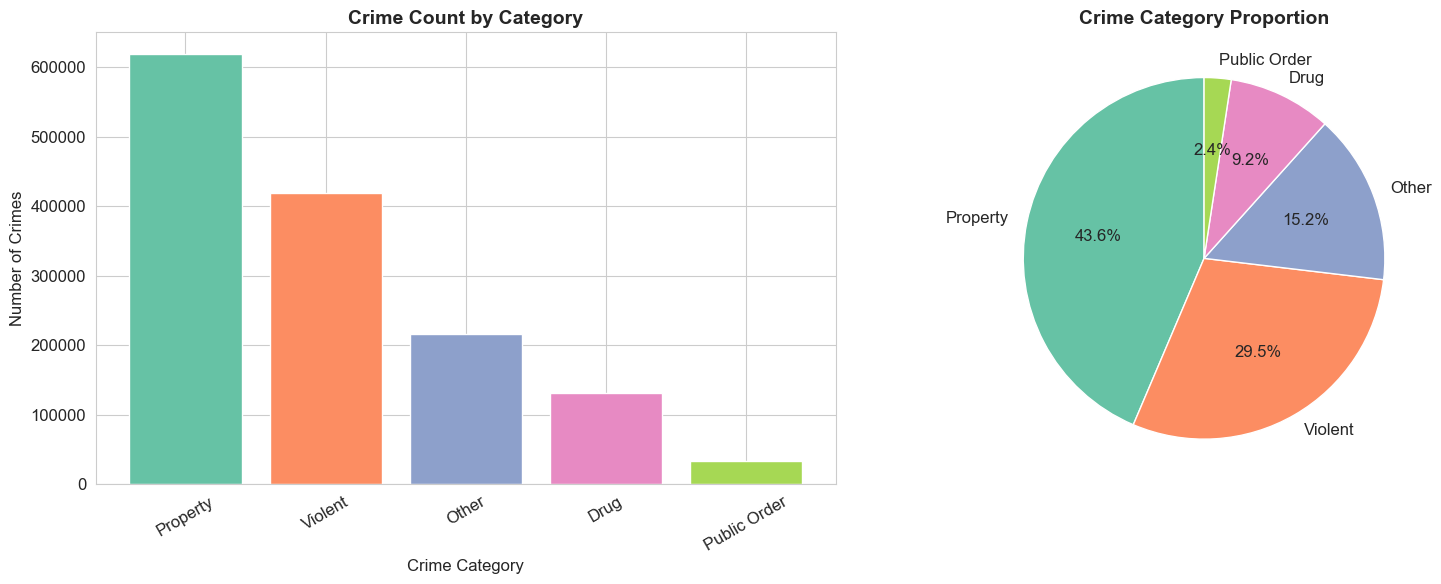

Chart 1 saved!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

crime_counts = df['Crime Category'].value_counts()

# Bar chart
axes[0].bar(crime_counts.index, crime_counts.values, color=sns.color_palette("Set2"))
axes[0].set_title('Crime Count by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Crime Category')
axes[0].set_ylabel('Number of Crimes')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(crime_counts.values, labels=crime_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette("Set2"), startangle=90)
axes[1].set_title('Crime Category Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/prernamalhotra/CRIME/crime-analysis-prediction/outputs/01_crime_category.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

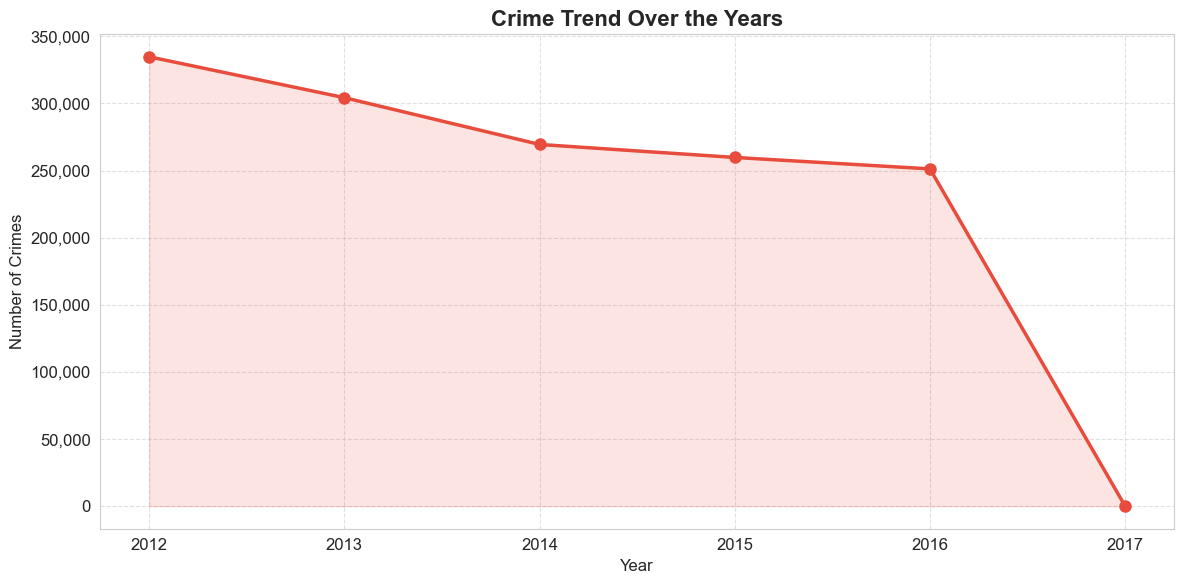

Chart 2 saved!


In [5]:
yearly = df.groupby('Year').size().reset_index(name='Count')

plt.figure(figsize=(12, 6))
plt.plot(yearly['Year'], yearly['Count'], marker='o', linewidth=2.5,
         markersize=8, color='#e74c3c')
plt.fill_between(yearly['Year'], yearly['Count'], alpha=0.15, color='#e74c3c')
plt.title('Crime Trend Over the Years', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/Users/prernamalhotra/CRIME/crime-analysis-prediction/outputs/02_crime_trend_yearly.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

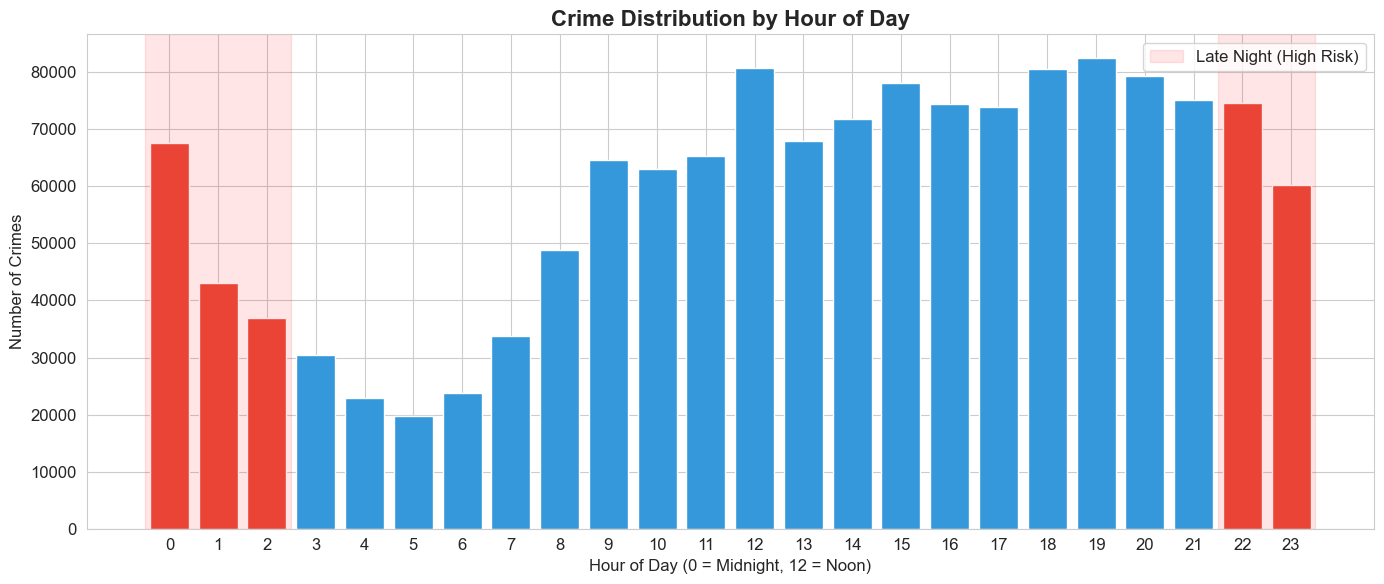

Chart 3 saved!


In [6]:
hourly = df.groupby('Hour').size().reset_index(name='Count')

plt.figure(figsize=(14, 6))
bars = plt.bar(hourly['Hour'], hourly['Count'],
               color=['#e74c3c' if h in [0,1,2,22,23] else '#3498db' for h in hourly['Hour']])
plt.title('Crime Distribution by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Number of Crimes')
plt.xticks(range(0, 24))
plt.axvspan(21.5, 23.5, alpha=0.1, color='red', label='Late Night (High Risk)')
plt.axvspan(-0.5, 2.5, alpha=0.1, color='red')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/prernamalhotra/CRIME/crime-analysis-prediction/outputs/03_crime_by_hour.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

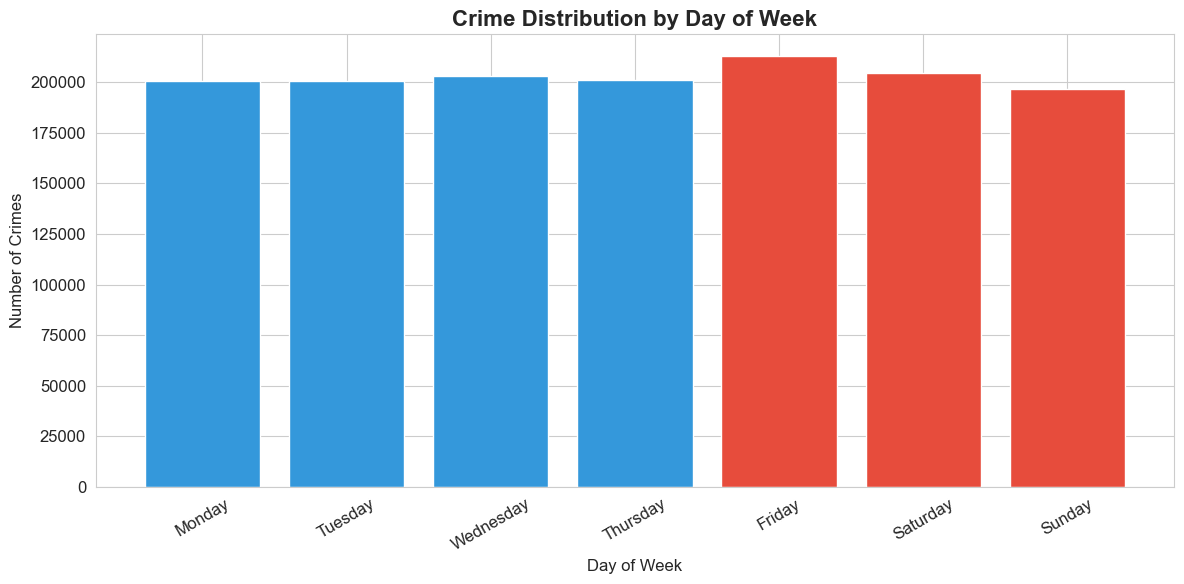

Chart 4 saved!


In [7]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('DayName').size().reindex(day_order).reset_index(name='Count')

plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if d in ['Friday','Saturday','Sunday'] else '#3498db' for d in day_order]
plt.bar(daily['DayName'], daily['Count'], color=colors)
plt.title('Crime Distribution by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('/Users/prernamalhotra/CRIME/crime-analysis-prediction/outputs/04_crime_by_day.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

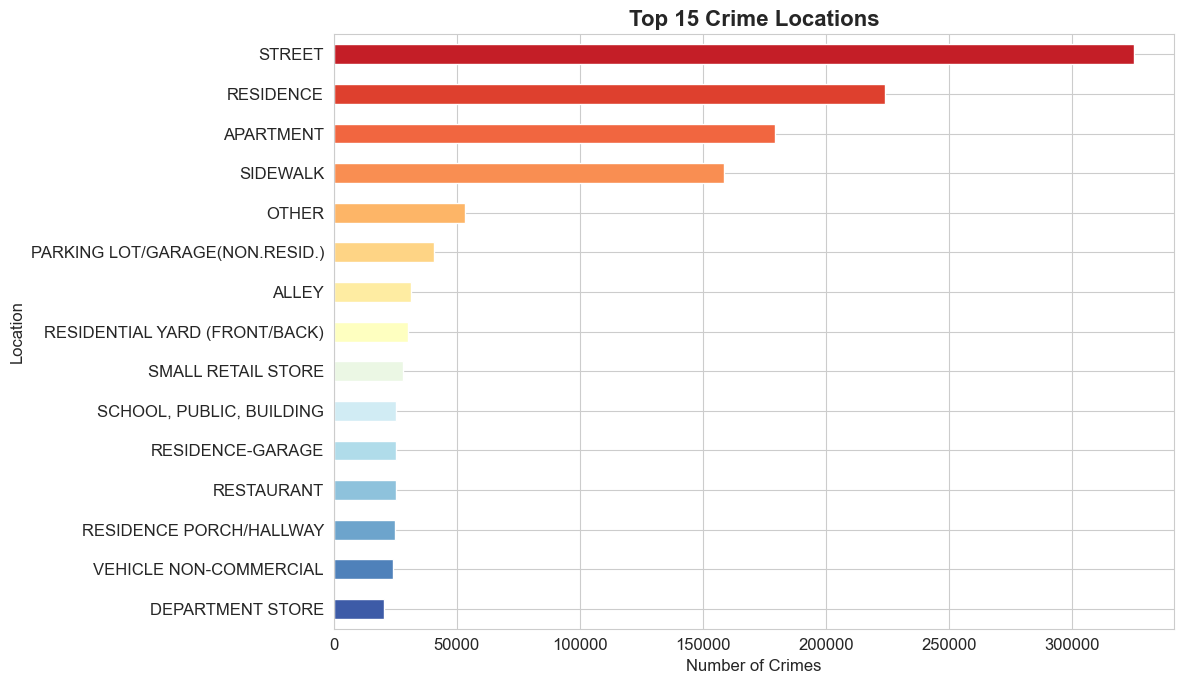

Chart 6 saved!


In [9]:
top_locations = df['Location Description'].value_counts().head(15)

plt.figure(figsize=(12, 7))
top_locations.plot(kind='barh', color=sns.color_palette("RdYlBu", 15))
plt.title('Top 15 Crime Locations', fontsize=16, fontweight='bold')
plt.xlabel('Number of Crimes')
plt.ylabel('Location')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/Users/prernamalhotra/CRIME/crime-analysis-prediction/outputs/06_top_locations.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")

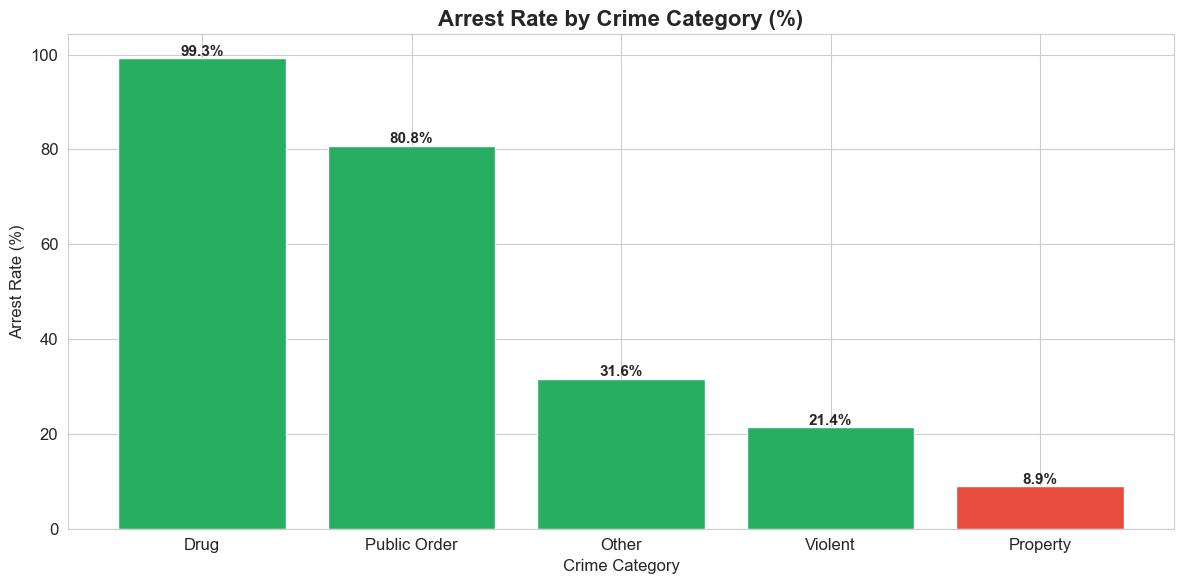

Chart 7 saved!


In [10]:
arrest_rate = df.groupby('Crime Category')['Arrest'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
bars = plt.bar(arrest_rate.index, arrest_rate.values,
               color=['#27ae60' if v > 20 else '#e74c3c' for v in arrest_rate.values])
plt.title('Arrest Rate by Crime Category (%)', fontsize=16, fontweight='bold')
plt.xlabel('Crime Category')
plt.ylabel('Arrest Rate (%)')
for bar, val in zip(bars, arrest_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/prernamalhotra/CRIME/crime-analysis-prediction/outputs/07_arrest_rate.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved!")